<a href="https://colab.research.google.com/github/deekshit-2007/machine-learning-/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mean (numpy) : 1560.6634538152612
Mean (mine)  : 1560.6634538152598
Variance (numpy): 58496.49239931613
Variance (mine) : 58496.49239931618

Avg time numpy mean : 7.524000000103115e-06
Avg time my_mean    : 3.288400000656111e-05

Population mean   : 1560.6634538152612
Wednesday mean    : 1550.7060000000001
April mean        : 1698.9526315789474

P(loss)                : 0.4979919678714859
P(profit AND Wednesday): 0.08433734939759036
P(profit | Wednesday)  : 0.42


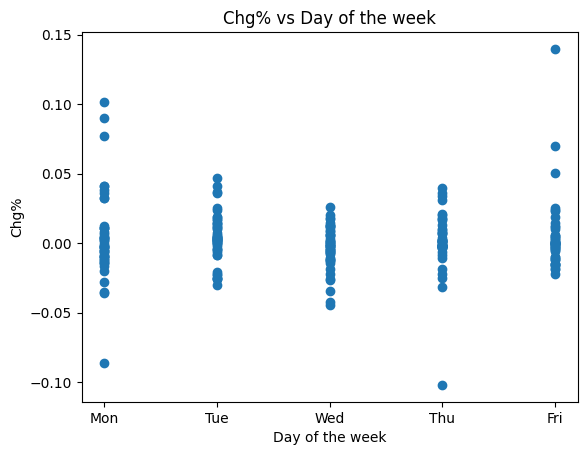

In [9]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

FILE = "Lab Session Data.xlsx"
def my_mean(values):
    """Add up all numbers and divide by how many there are."""
    total = 0.0
    for v in values:
        total = total + v
    return total / len(values)


def my_variance(values):
    """Average of squared distances from the mean (population variance)."""
    m = my_mean(values)
    squared_diff_sum = 0.0
    for v in values:
        squared_diff_sum = squared_diff_sum + (v - m) ** 2
    return squared_diff_sum / len(values)
def average_time(function, data, runs=10):
    start = time.perf_counter()
    for _ in range(runs):
        function(data)
    end = time.perf_counter()
    return (end - start) / runs
def prob_of_loss(chg_values):
    """A loss is any negative Chg% value. Probability = losses / total."""
    is_loss = list(filter(lambda x: x < 0, chg_values))   # lambda for negatives
    return len(is_loss) / len(chg_values)
def main():
    df = pd.read_excel(FILE, sheet_name="IRCTC Stock Price")
    price = df["Price"].values
    chg = df["Chg%"].values
    print("Mean (numpy) :", np.mean(price))
    print("Mean (mine)  :", my_mean(price))
    print("Variance (numpy):", np.var(price))
    print("Variance (mine) :", my_variance(price))
    print("\nAvg time numpy mean :", average_time(np.mean, price))
    print("Avg time my_mean    :", average_time(my_mean, price))
    wed_price = df[df["Day"] == "Wed"]["Price"].values
    print("\nPopulation mean   :", np.mean(price))
    print("Wednesday mean    :", np.mean(wed_price))
    apr_price = df[df["Month"] == "Apr"]["Price"].values
    print("April mean        :", np.mean(apr_price))
    p_loss = prob_of_loss(chg)
    print("\nP(loss)                :", p_loss)
    total_days = len(df)
    profit_and_wed = df[(df["Day"] == "Wed") & (df["Chg%"] > 0)]
    p_profit_wed = len(profit_and_wed) / total_days
    print("P(profit AND Wednesday):", p_profit_wed)
    wednesdays = df[df["Day"] == "Wed"]
    p_conditional = len(profit_and_wed) / len(wednesdays)
    print("P(profit | Wednesday)  :", p_conditional)
    day_order = {"Mon": 1, "Tue": 2, "Wed": 3, "Thu": 4, "Fri": 5}
    day_numbers = df["Day"].map(day_order)
    plt.scatter(day_numbers, df["Chg%"])
    plt.xticks([1, 2, 3, 4, 5], ["Mon", "Tue", "Wed", "Thu", "Fri"])
    plt.xlabel("Day of the week")
    plt.ylabel("Chg%")
    plt.title("Chg% vs Day of the week")
    plt.show()


main()

In [5]:
import numpy as np
from numpy.linalg import matrix_rank
import pandas as pd

df=pd.read_excel("Lab Session Data.xlsx",sheet_name="Purchase data",usecols="A:E")

X=df.iloc[:,1:4]
print(X)
Y=df.iloc[:,4]

print(Y)
print(X.shape)
print(Y.shape)
print(X.shape[0])
print(Y.shape[0])
print(matrix_rank(X))
print(matrix_rank(Y))
X_inv=np.linalg.pinv(X)
w=X_inv @ Y
print(w)


   Candies (#)  Mangoes (Kg)  Milk Packets (#)
0           20             6                 2
1           16             3                 6
2           27             6                 2
3           19             1                 2
4           24             4                 2
5           22             1                 5
6           15             4                 2
7           18             4                 2
8           21             1                 4
9           16             2                 4
0    386
1    289
2    393
3    110
4    280
5    167
6    271
7    274
8    148
9    198
Name: Payment (Rs), dtype: int64
(10, 3)
(10,)
10
10
3
1
[ 1. 55. 18.]


In [6]:
df["class"]=df["Payment (Rs)"].apply(lambda x:"RICH" if x>=200 else "POOR")
print(df["class"])

0    RICH
1    RICH
2    RICH
3    POOR
4    RICH
5    POOR
6    RICH
7    RICH
8    POOR
9    POOR
Name: class, dtype: object


In [7]:
df1=pd.read_excel("Lab Session Data.xlsx",sheet_name="thyroid0387_UCI",usecols="A:AE")
binary_cols=[]
for col in df1.columns:
  vlaues=set(df1[col].dropna().unique())
  if vlaues=={'t','f'}:
    binary_cols.append(col)
    df1[col]=df1[col].apply(lambda x:1 if x=='t' else 0)

row1=df1.loc[0,binary_cols]
row2=df1.loc[1,binary_cols]
f00=f01=f10=f11=0

for a,b in zip(row1,row2):
  if a==0 and b==0:
    f00+=1
  elif a==0 and b==1:
    f01+=1
  elif a==1 and b==0:
    f10+=1
  elif a==1 and b==1:
    f11+=1

JC=f11/(f10+f01+f11)
SMC=(f11+f00)/(f00+f01+f10+f11)

print("JC",JC)
print("SMC",SMC)
print("f11",f11)


JC 0.25
SMC 0.85
f11 1


In [8]:
for col in df1.columns:
  print("attribute",col)
  print(df1[col].dtype)
  print(df1[col].unique())

numeric=df1.select_dtypes(include=['int64','float64'])

for col in numeric.columns:
  print(col)
  print('minimum',numeric[col].min())
  print('maximun',numeric[col].max())
  print('mean',numeric[col].mean())
  print('median',numeric[col].median())
  print('mode',numeric[col].mode())


print(df1.isnull().sum())
print((df1=='?').sum())


attribute Record ID
int64
[840801013 840801014 840801042 ... 870119025 870119027 870119035]
attribute age
int64
[   29    41    36    32    60    77    28    54    42    51    37    16
    43    63    40    75    56    85    71    67    55    61    46    44
    82    64    70    33    59    53    52    49    35    48    27    69
    76    73    68    66    30    88    38    58    21    45    83    62
    25    86    72    14    15    39    26    20    80    90    23    18
    13    78    24    81    92    57    74     9    47    17    11    50
    34     8    79    31    65    84    12    10    19    22     1     2
    97     6    89    87   455    93     7    91     5    94     4 65511
    95 65512     3 65526]
attribute sex
object
['F' 'M' '?']
attribute on thyroxine
int64
[0 1]
attribute query on thyroxine
int64
[0 1]
attribute on antithyroid medication
int64
[0 1]
attribute sick
int64
[0 1]
attribute pregnant
int64
[0 1]
attribute thyroid surgery
int64
[0 1]
attribute I131 treatmen